In [42]:
import pandas as pd
import joblib
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt


In [43]:
# We are calling our train_df as historical_df.
historical_df = pd.read_csv('../data/historical.csv')

# the model by data monitors as old_model
old_model = joblib.load("../data/model.joblib")

C:\Users\loren\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\loren\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\loren\Ap

In [44]:
# Predictions
old_pred = old_model.predict(historical_df)

# Encode labels
historical_df['risk_level'] = np.where(historical_df['risk_level'] == 'At Risk', 1, 0)
real = historical_df["risk_level"]

# Get classification report as dict
report_dict = classification_report(real, old_pred, output_dict=True)

# Convert to DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Round values for readability
report_df = report_df.round(3)


report_df

,precision,recall,f1-score,support
0,0.941,0.974,0.957,1822.000
1,0.777,0.601,0.677,278.000
accuracy,0.924,0.924,0.924,0.924
macro avg,0.859,0.787,0.817,2100.000
weighted avg,0.919,0.924,0.920,2100.000


## Classification Report

### The old model has a high accuracy of about 92%, which could be misleading because of the imbalanced dataset. Its poor recall of 60% in class 1 mean that it missed 40% of the actual at-risk babies, which is counter-intuitive with the goal of catching those that are at risk. 

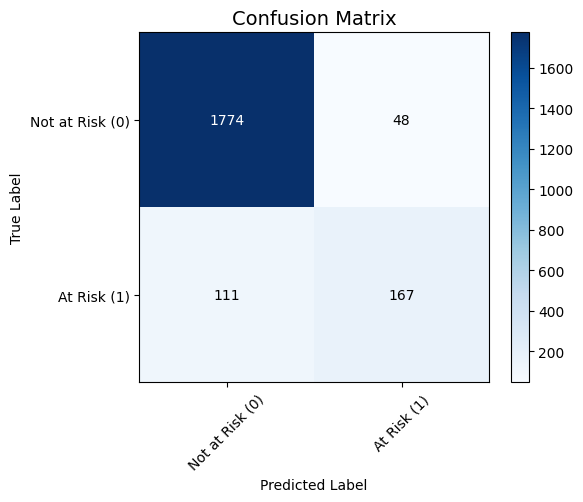

In [47]:
cm = confusion_matrix(real, old_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix", fontsize=14)
plt.colorbar()

# Tick marks
classes = ["Not at Risk (0)", "At Risk (1)"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


## Confusion Matrix

### This model has high false negatives at 111, meaning they missed alot of the "at-risk" babies